# NYC Restaurant Intelligence Platform — Market Overview
## Notebook 03: Geographic Analysis and Neighbourhood Drill-Down

**Input**: `data/cleaned/restaurants.csv`, `data/cleaned/borough_boundaries.csv`, and
`data/raw/nta_population_2010.csv` (NYC Open Data reference file, see section 1.1)
**Output**: maps and charts in `reports/figures/`

### Why this notebook exists

Notebook 02 ended on a warning: borough-level averages hide what happens inside a borough.
"Brooklyn has 29.0 restaurants per 10,000 residents" describes a borough that contains both
one of the densest dining corridors in the city and large residential tracts with almost
nothing. This notebook measures that internal variation and puts the data on a map.

### Questions
1. Where are the restaurants actually concentrated, geographically?
2. How much does density vary *within* a borough, not just between boroughs?
3. Which neighbourhoods are large but narrow — many restaurants, few cuisines?

> **A note on tooling**: these maps are drawn with matplotlib rather than folium.
> Interactive folium maps are saved as HTML and **do not render on GitHub** — they appear
> as a blank cell. Static images render everywhere, which matters for a repository meant
> to be read. The boundary geometry is parsed from WKT directly, so the notebook needs no
> geospatial dependencies beyond what notebooks 01 and 02 already use.

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEANED = PROJ / "data" / "cleaned"
FIGURES = PROJ / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RAW = PROJ / "data" / "raw"

restaurants = pd.read_csv(CLEANED / "restaurants.csv")
boundaries = pd.read_csv(CLEANED / "borough_boundaries.csv")

# NTA reference: code -> neighbourhood name + resident population.
# Source: NYC Open Data "New York City Population By Neighborhood Tabulation Areas"
# (dataset swpk-hqdp). See data/raw/README.md for the download command.
nta_ref = (
    pd.read_csv(RAW / "nta_population_2010.csv")
    .query("year == 2010")
    .set_index("nta_code")[["nta_name", "population"]]
)

print(f"Restaurants:   {len(restaurants):,}")
print(f"Boundaries:    {len(boundaries)} boroughs")
print(f"NTA reference: {len(nta_ref)} neighbourhoods")

Restaurants:   31,222
Boundaries:    5 boroughs
NTA reference: 195 neighbourhoods


In [2]:
# --- Shared chart configuration (same palette as notebook 02) ---
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

BLUE = "#2a78d6"
INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e5e4e0"
LAND = "#f0efec"      # neutral fill for borough shapes
COAST = "#c9c8c3"     # borough outline

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 10, "axes.grid": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False,
})

# NYC sits at ~40.7 deg N, where one degree of longitude is much shorter than one of
# latitude. Without this correction every map comes out horizontally squashed.
NYC_ASPECT = 1 / np.cos(np.radians(40.7))
print(f"Map aspect ratio: {NYC_ASPECT:.3f}")

Map aspect ratio: 1.319


### 1.1 The NTA reference file

The inspection data identifies neighbourhoods only by code (`MN17`, `QN22`). Codes are
unreadable, so this notebook joins the official reference table, which supplies both the
**name** and the **resident population** of each neighbourhood — the latter unlocking
per-capita analysis at neighbourhood resolution (section 7).

**A version trap worth knowing about.** NYC has two incompatible generations of NTA
geography. The DOHMH data uses **2010 NTAs** (four-character codes: `MN17`). NYC Open Data
now publishes **2020 NTAs** (six-character codes: `MN0101`) with different boundaries. The
two do not join. Everything here uses the 2010 vintage to match the source data.

One consequence: the 2010 NTA **polygons** are no longer on the open data portal, so this
notebook still cannot draw a true neighbourhood choropleth. Names and population are
available; boundaries are not.

In [3]:
# Verify the join before relying on it — a silent partial match would quietly
# drop neighbourhoods from every chart downstream.
our_codes = set(restaurants["nta"].dropna().unique())
ref_codes = set(nta_ref.index)

print(f"NTA codes in restaurant data: {len(our_codes)}")
print(f"NTA codes in reference file:  {len(ref_codes)}")
print(f"Matched: {len(our_codes & ref_codes)} / {len(our_codes)}")
print(f"Unmatched in our data: {sorted(our_codes - ref_codes) or 'none'}")
print(f"In reference but with no restaurants: {sorted(ref_codes - our_codes)}")

assert our_codes <= ref_codes, "Some NTA codes have no reference entry"

restaurants = restaurants.join(nta_ref, on="nta")

print("\nExamples:")
for code in ["MN17", "QN22", "BK73", "BX37", "SI45"]:
    row = nta_ref.loc[code]
    print(f"  {code} -> {row['nta_name']}  (population {row['population']:,})")

NTA codes in restaurant data: 193
NTA codes in reference file:  195
Matched: 193 / 193
Unmatched in our data: none
In reference but with no restaurants: ['BX98', 'SI99']

Examples:
  MN17 -> Midtown-Midtown South  (population 28,630)
  QN22 -> Flushing  (population 72,008)
  BK73 -> North Side-South Side  (population 45,774)
  BX37 -> Van Nest-Morris Park-Westchester Square  (population 29,250)
  SI45 -> New Dorp-Midland Beach  (population 21,896)


## 1. Parsing the borough geometry

The boundary file stores each borough as a WKT `MULTIPOLYGON` string. Boroughs are made of
many separate rings — Queens alone has 23, because every island counts. The helper below
extracts each ring as an array of coordinates, which is all that is needed to draw outlines
and filled shapes.

In [4]:
RING_RE = re.compile(r"\(([-0-9\.\s,]+)\)")


def wkt_rings(wkt: str) -> list[np.ndarray]:
    """Extract coordinate rings from a WKT MULTIPOLYGON as (n, 2) lon/lat arrays."""
    return [
        np.array([[float(v) for v in point.split()] for point in group.split(",")])
        for group in RING_RE.findall(wkt)
    ]


boundaries["rings"] = boundaries["geometry_wkt"].apply(wkt_rings)

summary = pd.DataFrame({
    "borough": boundaries["boro_name"],
    "n_rings": boundaries["rings"].apply(len),
    "n_points": boundaries["rings"].apply(lambda rs: sum(len(r) for r in rs)),
})
display(summary.sort_values("n_rings", ascending=False))

# Sanity check: everything must land inside the NYC bounding box
all_pts = np.vstack([r for rs in boundaries["rings"] for r in rs])
assert all_pts[:, 0].min() > -74.3 and all_pts[:, 0].max() < -73.6, "longitude out of range"
assert all_pts[:, 1].min() > 40.4 and all_pts[:, 1].max() < 41.0, "latitude out of range"
print(f"\nParsed {len(all_pts):,} boundary points, all inside the NYC bounding box.")

,borough,n_rings,n_points
3,Manhattan,37,6124
1,Brooklyn,28,20907
4,Bronx,26,8980
2,Queens,23,36089
0,Staten Island,4,8985



Parsed 81,085 boundary points, all inside the NYC bounding box.


In [5]:
def draw_boroughs(ax, face=LAND, edge=COAST, lw=0.6, zorder=0):
    """Draw all borough shapes as the base layer of a map."""
    for rings in boundaries["rings"]:
        for ring in rings:
            ax.fill(ring[:, 0], ring[:, 1], facecolor=face, edgecolor=edge,
                    linewidth=lw, zorder=zorder)


def style_map(ax):
    """Maps carry no axes — coordinates are not the point."""
    ax.set_aspect(NYC_ASPECT)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ax.spines:
        ax.spines[side].set_visible(False)


print("Map helpers ready")

Map helpers ready


## 2. Where are the restaurants?

The cleaned data has coordinates for 30,417 of 31,222 restaurants (97.4%) — the rest were
never geocoded, as documented in Notebook 01 (issues O-03 and M-04).

A scatter plot of 30,000 points would be a solid blob in Manhattan and tell us nothing, so
density is binned into hexagons. The count per hexagon spans several orders of magnitude,
so the colour scale is logarithmic — stated on the legend, because an unlabelled log scale
silently flattens differences.

In [6]:
mapped = restaurants.dropna(subset=["latitude", "longitude"])
print(f"Mappable restaurants: {len(mapped):,} of {len(restaurants):,} "
      f"({len(mapped)/len(restaurants):.1%})")
print(f"Missing coordinates:  {len(restaurants) - len(mapped):,}")

Mappable restaurants: 30,417 of 31,222 (97.4%)
Missing coordinates:  805


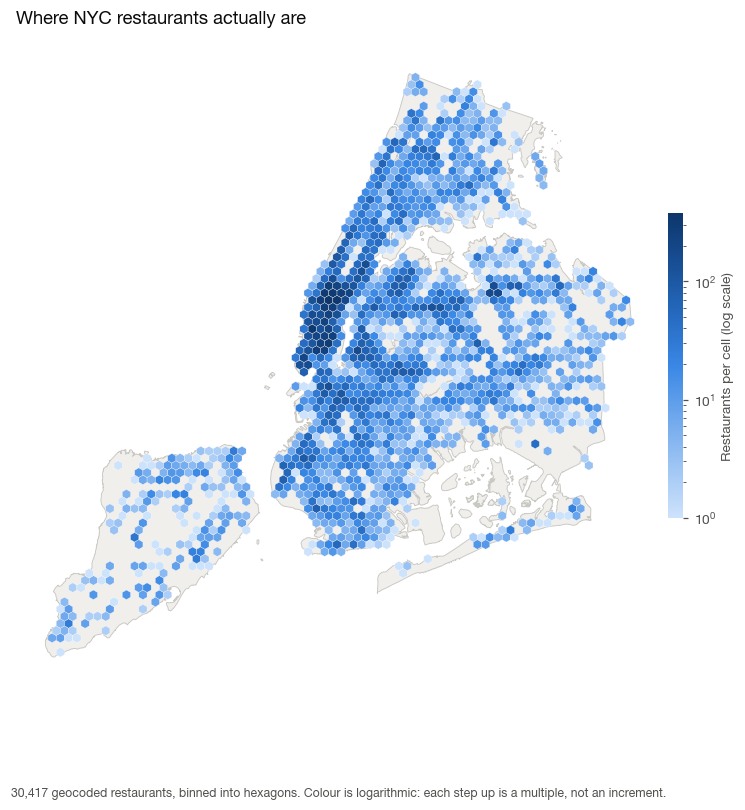

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))

draw_boroughs(ax)
hb = ax.hexbin(
    mapped["longitude"], mapped["latitude"],
    gridsize=70, bins="log", cmap=CMAP_SEQ, mincnt=1,
    linewidths=0.2, edgecolors="white", zorder=2,
)
style_map(ax)

cbar = fig.colorbar(hb, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label("Restaurants per cell (log scale)", fontsize=9, color=INK_SOFT)
cbar.outline.set_visible(False)

ax.set_title("Where NYC restaurants actually are", loc="left")
fig.text(0.12, 0.06, f"{len(mapped):,} geocoded restaurants, binned into hexagons. "
                     "Colour is logarithmic: each step up is a multiple, not an increment.",
         fontsize=8, color=INK_SOFT)
plt.savefig(FIGURES / "06_restaurant_density_map.png")
plt.show()

**Reading the map**

The pattern is not "Manhattan is dense and everywhere else is not". It is a **corridor
structure**: an unbroken high-density spine runs the length of Manhattan, spills across the
East River into north-west Brooklyn and western Queens, then thins out sharply. Outer
Staten Island, eastern Queens and the north-east Bronx are close to empty by comparison.

This is the first visual evidence that borough boundaries are the wrong unit of analysis —
the dense zone crosses three boroughs and stops well short of any borough edge.

## 3. Borough choropleth

The same density figure from Notebook 02, drawn on the actual geography rather than as bars.
This is the conventional view — and section 4 shows why it is misleading.

In [8]:
POPULATION_2020 = {
    "Manhattan": 1_694_251, "Brooklyn": 2_736_074, "Queens": 2_405_464,
    "Bronx": 1_472_654, "Staten Island": 495_747,
}

boro_density = (
    restaurants[restaurants["boro"] != "Unknown"]["boro"].value_counts()
    .rename("restaurants").to_frame()
    .join(pd.Series(POPULATION_2020, name="population"))
    .assign(per_10k=lambda d: (d["restaurants"] / d["population"] * 10000).round(1))
)
display(boro_density.sort_values("per_10k", ascending=False))

,restaurants,population,per_10k
boro,,,
Manhattan,12446,1694251,73.5
Queens,7003,2405464,29.1
Brooklyn,7945,2736074,29.0
Staten Island,1111,495747,22.4
Bronx,2632,1472654,17.9


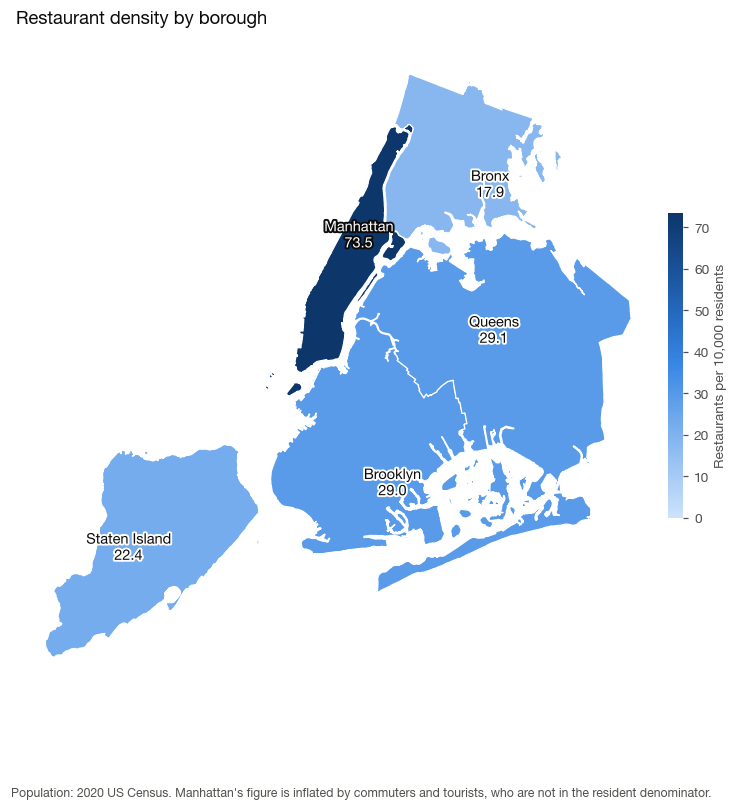

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))

vmin, vmax = boro_density["per_10k"].min(), boro_density["per_10k"].max()
norm = plt.Normalize(vmin=0, vmax=vmax)

for _, row in boundaries.iterrows():
    value = boro_density.loc[row["boro_name"], "per_10k"]
    colour = CMAP_SEQ(norm(value))
    for ring in row["rings"]:
        ax.fill(ring[:, 0], ring[:, 1], facecolor=colour, edgecolor="white",
                linewidth=0.8, zorder=1)

# Label each borough at the centroid of its largest ring
for _, row in boundaries.iterrows():
    biggest = max(row["rings"], key=len)
    cx, cy = biggest[:, 0].mean(), biggest[:, 1].mean()
    value = boro_density.loc[row["boro_name"], "per_10k"]
    dark_fill = norm(value) > 0.55
    ax.text(cx, cy, f"{row['boro_name']}\n{value}", ha="center", va="center",
            fontsize=9.5, fontweight="bold",
            color="white" if dark_fill else INK, zorder=3,
            # Manhattan's label is wider than Manhattan; the stroke keeps it readable
            # where the text overhangs the polygon onto the background
            path_effects=[pe.withStroke(linewidth=2.5,
                                        foreground=INK if dark_fill else "white")])

style_map(ax)
sm = plt.cm.ScalarMappable(cmap=CMAP_SEQ, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label("Restaurants per 10,000 residents", fontsize=9, color=INK_SOFT)
cbar.outline.set_visible(False)

ax.set_title("Restaurant density by borough", loc="left")
fig.text(0.12, 0.06, "Population: 2020 US Census. Manhattan's figure is inflated by "
                     "commuters and tourists, who are not in the resident denominator.",
         fontsize=8, color=INK_SOFT)
plt.savefig(FIGURES / "07_borough_density_choropleth.png")
plt.show()

## 4. The problem with borough averages

Five shaded polygons imply five internally uniform markets. They are not. The city's
official neighbourhood units — **NTAs** (Neighbourhood Tabulation Areas, 193 of them) —
let us measure the variation each borough average conceals.

In [10]:
# One NTA code appears under two boroughs; assign each NTA to its dominant borough
cross = restaurants.groupby("nta")["boro"].nunique()
if (cross > 1).any():
    odd = cross[cross > 1].index.tolist()
    print(f"NTA codes spanning more than one borough: {odd}")
    print(restaurants[restaurants["nta"].isin(odd)].groupby(["nta", "boro"]).size().to_string())
    print("\nThis is an administrative boundary quirk, not a data error. Each NTA is")
    print("assigned to the borough holding the majority of its restaurants.\n")

nta_boro = restaurants.groupby("nta")["boro"].agg(lambda s: s.mode()[0])

nta_stats = (
    restaurants.dropna(subset=["nta"])
    .groupby("nta")
    .agg(restaurants=("camis", "size"),
         latitude=("latitude", "mean"),
         longitude=("longitude", "mean"))
    .join(nta_boro.rename("boro"))
    .join(nta_ref)
    .query("boro != 'Unknown'")
)

print(f"NTAs analysed: {len(nta_stats)}")
print(f"Restaurants without an NTA code: {restaurants['nta'].isna().sum():,}")

NTA codes spanning more than one borough: ['MN01']
nta   boro     
MN01  Bronx         11
      Manhattan    130

This is an administrative boundary quirk, not a data error. Each NTA is
assigned to the borough holding the majority of its restaurants.

NTAs analysed: 193
Restaurants without an NTA code: 805


In [11]:
spread = (
    nta_stats.groupby("boro")["restaurants"]
    .agg(n_ntas="count", smallest="min", median="median", largest="max")
    .assign(ratio=lambda d: (d["largest"] / d["smallest"]).round(1))
    .sort_values("ratio", ascending=False)
)
display(spread)

print("The 'ratio' column is the largest NTA divided by the smallest, within that borough.")
print(f"Manhattan's most and least restaurant-dense neighbourhoods differ by "
      f"{spread.loc['Manhattan', 'ratio']:.0f}x — inside a single borough.")

,n_ntas,smallest,median,largest,ratio
boro,,,,,
Manhattan,29,11,238.0,2258,205.3
Brooklyn,51,14,116.0,573,40.9
Queens,58,18,63.0,615,34.2
Staten Island,18,7,58.5,104,14.9
Bronx,37,20,64.0,155,7.8


The 'ratio' column is the largest NTA divided by the smallest, within that borough.
Manhattan's most and least restaurant-dense neighbourhoods differ by 205x — inside a single borough.


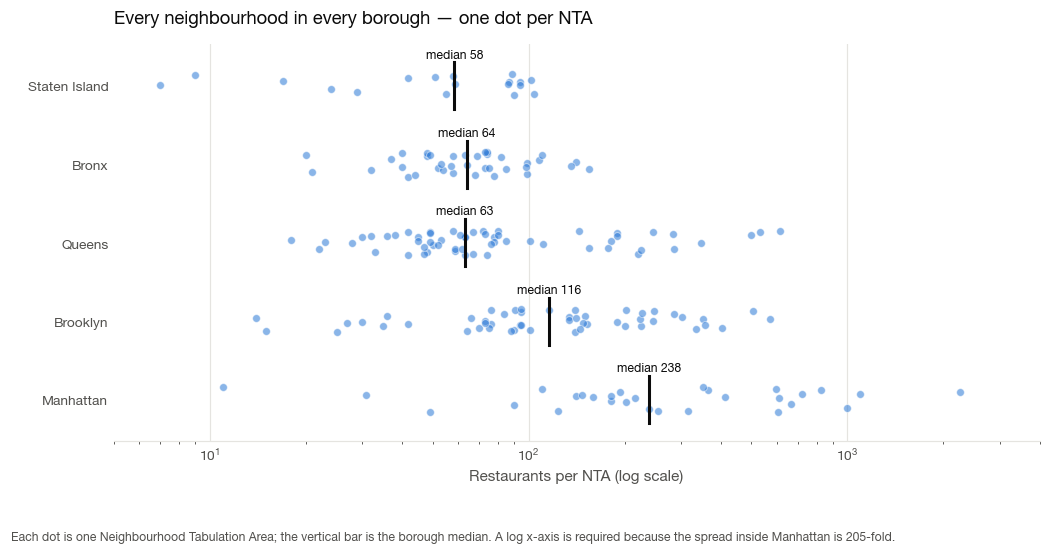

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

BORO_ORDER = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
rng = np.random.default_rng(0)

for i, boro in enumerate(BORO_ORDER):
    vals = nta_stats.loc[nta_stats["boro"] == boro, "restaurants"].values
    # Vertical jitter so overlapping NTAs stay countable
    y = i + rng.uniform(-0.16, 0.16, len(vals))
    ax.scatter(vals, y, s=26, color=BLUE, alpha=0.55, edgecolor="white",
               linewidth=0.6, zorder=3)
    # The borough median, as the reference an average would give you
    med = np.median(vals)
    ax.plot([med, med], [i - 0.3, i + 0.3], color=INK, lw=2, zorder=4)
    ax.text(med, i + 0.36, f"median {med:.0f}", ha="center", fontsize=8, color=INK)

ax.set_yticks(range(len(BORO_ORDER)))
ax.set_yticklabels(BORO_ORDER)
ax.set_xscale("log")
ax.set_xlabel("Restaurants per NTA (log scale)")
ax.set_xlim(5, 4000)
ax.grid(axis="x", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)

ax.set_title("Every neighbourhood in every borough — one dot per NTA", loc="left")
fig.text(0.0, -0.08, "Each dot is one Neighbourhood Tabulation Area; the vertical bar is the "
                     "borough median. A log x-axis is required because the spread inside "
                     "Manhattan is 205-fold.",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "08_nta_spread_within_borough.png")
plt.show()

**Reading the chart**

Each borough's dots span one to two orders of magnitude. Manhattan is the extreme: its
busiest NTA holds **2,258 restaurants** and its quietest **11** — a **205x** difference
inside one borough. Brooklyn spans 41x, Queens 34x.

Put differently: the gap between Manhattan and the Bronx (4.1x, the headline of Notebook 02)
is **smaller than the gap between two neighbourhoods of the Bronx** (14x). Any strategy
built on the borough average is being fitted to a number that describes almost none of the
actual neighbourhoods.

## 5. Locating the largest neighbourhood markets

NTA codes (`MN17`, `QN22`) are opaque on their own — the boundary file we have does not
carry their names. Two things make them usable: plotting them in position, and tagging each
with its dominant ZIP code, which can be looked up directly.

In [13]:
# A lookup-able anchor for each NTA, since we have no NTA name reference
dominant_zip = (
    restaurants.dropna(subset=["nta", "zipcode"])
    .astype({"zipcode": "Int64"})
    .groupby("nta")["zipcode"]
    .agg(lambda s: s.mode()[0])
)

top_ntas = (
    nta_stats.join(dominant_zip.rename("main_zip"))
    .sort_values("restaurants", ascending=False)
    .head(15)
)
display(top_ntas[["nta_name", "boro", "restaurants", "population", "main_zip"]])

,nta_name,boro,restaurants,population,main_zip
nta,,,,,
MN17,Midtown-Midtown South,Manhattan,2258,28630,10036
MN13,Hudson Yards-Chelsea-Flat Iron-Union Square,Manhattan,1091,70150,10011
MN23,West Village,Manhattan,994,66880,10014
MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,824,42742,10013
MN22,East Village,Manhattan,719,44136,10003
MN27,Chinatown,Manhattan,665,47844,10002
QN22,Flushing,Queens,615,72008,11354
MN25,Battery Park City-Lower Manhattan,Manhattan,610,39699,10038
MN19,Turtle Bay-East Midtown,Manhattan,606,51231,10022


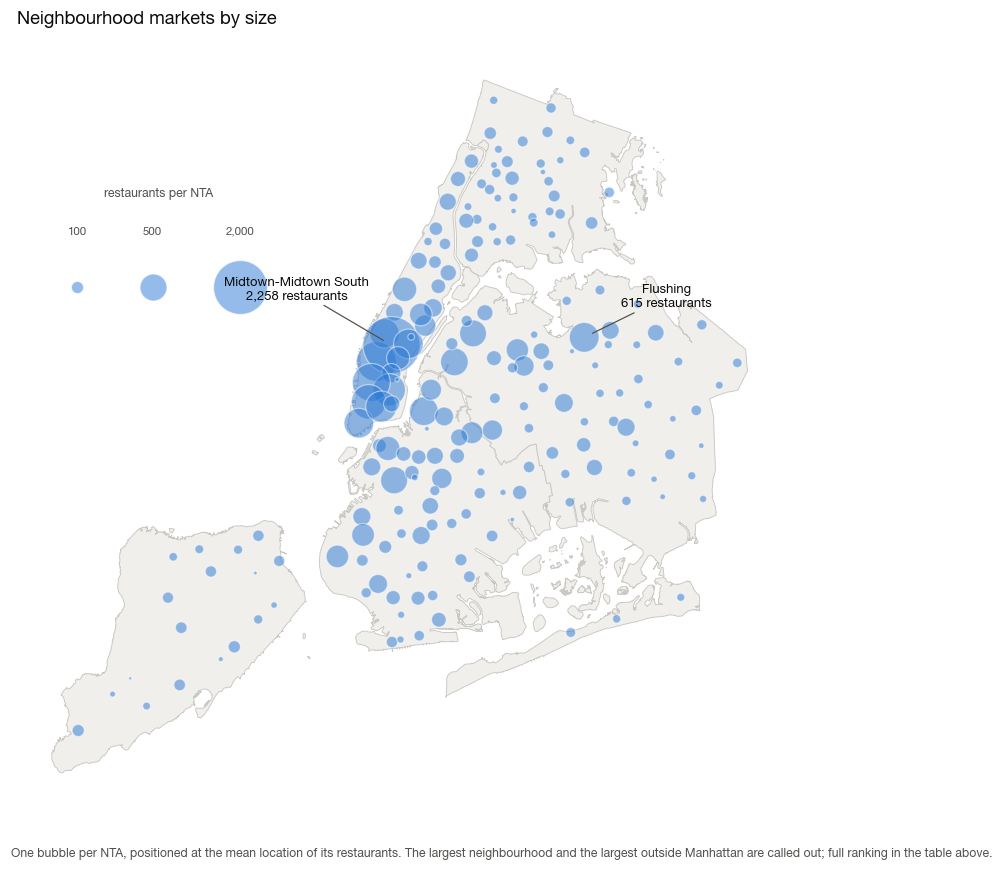

In [14]:
fig, ax = plt.subplots(figsize=(9, 9))

draw_boroughs(ax)

# Bubble area proportional to restaurant count, so the visual and the number agree
sizes = nta_stats["restaurants"] / nta_stats["restaurants"].max() * 1400
ax.scatter(nta_stats["longitude"], nta_stats["latitude"], s=sizes,
           color=BLUE, alpha=0.5, edgecolor="white", linewidth=0.8, zorder=3)

# The eight largest NTAs are packed into the Manhattan core, so labelling them all
# produces an unreadable pile. Label the two that carry the story and let the table
# above supply the rest.
CALLOUTS = {
    top_ntas.index[0]: (-62, 30),   # largest in the city
    "QN22": (54, 20),               # the outer-borough standout
}
for nta, offset in CALLOUTS.items():
    row = nta_stats.loc[nta]
    ax.annotate(f"{row['nta_name']}\n{row['restaurants']:,.0f} restaurants",
                (row["longitude"], row["latitude"]),
                textcoords="offset points", xytext=offset,
                ha="center", fontsize=8.5, fontweight="bold", color=INK, zorder=5,
                arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=0.8,
                                shrinkA=0, shrinkB=6))

style_map(ax)

# Size legend, since bubble area has no axis to read it from. Placed in the empty
# water west of Manhattan — high enough to avoid Staten Island, low enough to clear
# the title.
for value, xpos in zip([100, 500, 2000], [-74.235, -74.175, -74.105]):
    ax.scatter([xpos], [40.79], s=value / nta_stats["restaurants"].max() * 1400,
               color=BLUE, alpha=0.5, edgecolor="white", linewidth=0.8)
    ax.text(xpos, 40.822, f"{value:,}", ha="center", fontsize=7.5, color=INK_SOFT)
ax.text(-74.17, 40.845, "restaurants per NTA", ha="center", fontsize=8, color=INK_SOFT)

ax.set_title("Neighbourhood markets by size", loc="left")
fig.text(0.12, 0.06, "One bubble per NTA, positioned at the mean location of its "
                     "restaurants. The largest neighbourhood and the largest outside "
                     "Manhattan are called out; full ranking in the table above.",
         fontsize=8, color=INK_SOFT)
plt.savefig(FIGURES / "09_nta_market_size_map.png")
plt.show()

**Reading the map**

`MN17` alone holds **2,258 restaurants** — more than the entire Bronx borough (2,632 comes
close, but MN17 is one neighbourhood against 38). The top eight NTAs are all in the Manhattan
core except `QN22`, which stands out as a large outer-borough cluster.

Bubble positions are the mean coordinate of each NTA's restaurants, not the geometric centre
of the neighbourhood — close enough to locate them, but not an official boundary.

## 6. Size is not the same as variety

A neighbourhood with 500 restaurants that are nearly all one cuisine is a very different
market from one with 500 spread across fifty. **Shannon diversity** captures this: it is
highest when restaurants are spread evenly across many cuisines, and falls as they
concentrate into a few.

Reading the scale: a diversity of 3.4 corresponds to roughly 30 cuisines competing on even
terms; 1.5 corresponds to about 4.

In [15]:
known = restaurants[~restaurants["cuisine"].isin(["UNKNOWN", "OTHER"])].dropna(subset=["nta"])


def shannon(series: pd.Series) -> float:
    """Shannon entropy of a cuisine mix; higher = more evenly spread across more cuisines."""
    p = series.value_counts(normalize=True)
    return float(-(p * np.log(p)).sum())


MIN_STORES = 50
diversity = (
    known.groupby("nta")
    .agg(restaurants=("camis", "size"),
         n_cuisines=("cuisine", "nunique"),
         diversity=("cuisine", shannon),
         latitude=("latitude", "mean"),
         longitude=("longitude", "mean"))
    .join(nta_boro.rename("boro"))
    .join(nta_ref)
    .query("boro != 'Unknown' and restaurants >= @MIN_STORES")
)

print(f"NTAs with at least {MIN_STORES} restaurants: {len(diversity)}")
COLS = ["nta_name", "boro", "restaurants", "n_cuisines", "diversity"]
print("\nMost diverse:")
display(diversity.sort_values("diversity", ascending=False).head(5)[COLS].round(2))
print("Least diverse:")
display(diversity.sort_values("diversity").head(5)[COLS].round(2))

NTAs with at least 50 restaurants: 136

Most diverse:


,nta_name,boro,restaurants,n_cuisines,diversity
nta,,,,,
QN70,Astoria,Queens,436,51,3.39
QN17,Forest Hills,Queens,220,41,3.25
BK73,North Side-South Side,Brooklyn,481,58,3.24
QN72,Steinway,Queens,159,39,3.24
BK38,DUMBO-Vinegar Hill-Downtown Brklyn-Boerum Hill,Brooklyn,353,54,3.24


Least diverse:


,nta_name,boro,restaurants,n_cuisines,diversity
nta,,,,,
BK96,Rugby-Remsen Village,Brooklyn,66,11,1.52
BK43,Midwood,Brooklyn,76,15,1.85
QN22,Flushing,Queens,514,35,1.99
BX03,Eastchester-Edenwald-Baychester,Bronx,50,13,2.06
QN51,Murray Hill,Queens,195,24,2.10


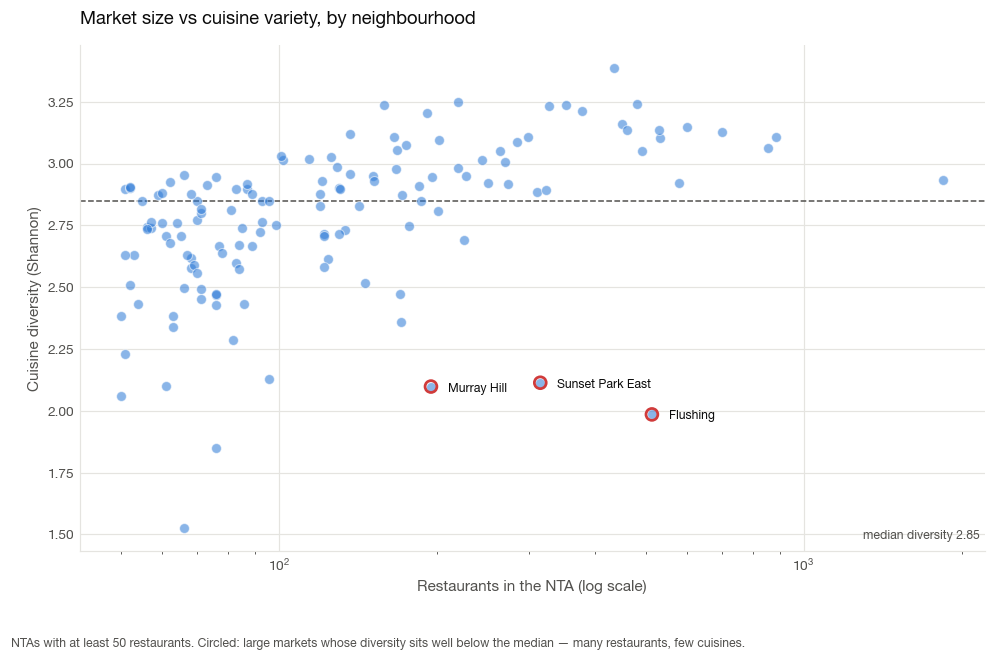

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.6))

ax.scatter(diversity["restaurants"], diversity["diversity"], s=42,
           color=BLUE, alpha=0.55, edgecolor="white", linewidth=0.7, zorder=3)

# Call out the informative outliers: large but narrow, and the diversity ceiling
median_div = diversity["diversity"].median()
ax.axhline(median_div, color=INK_SOFT, lw=1, ls="--", zorder=1)
# Anchored bottom-right, the one corner of this plot with no points in it
ax.text(0.995, 0.02, f"median diversity {median_div:.2f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color=INK_SOFT, style="italic")

big_narrow = diversity[(diversity["restaurants"] > 150) &
                       (diversity["diversity"] < median_div - 0.55)]
for nta, row in big_narrow.iterrows():
    ax.annotate(f"{row['nta_name']}",
                (row["restaurants"], row["diversity"]),
                textcoords="offset points", xytext=(11, -3),
                fontsize=8, color=INK, fontweight="bold", zorder=5)
ax.scatter(big_narrow["restaurants"], big_narrow["diversity"], s=60,
           facecolor="none", edgecolor="#d03b3b", linewidth=1.8, zorder=4)

ax.set_xscale("log")
ax.set_xlabel("Restaurants in the NTA (log scale)")
ax.set_ylabel("Cuisine diversity (Shannon)")
ax.grid(color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)

ax.set_title("Market size vs cuisine variety, by neighbourhood", loc="left")
fig.text(0.0, -0.06, f"NTAs with at least {MIN_STORES} restaurants. Circled: large markets "
                     "whose diversity sits well below the median — many restaurants, few cuisines.",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "10_size_vs_diversity.png")
plt.show()

**Reading the chart**

Diversity rises with size, but only up to a point — past roughly 200 restaurants the cloud
flattens near 3.2, which looks like a practical ceiling on how many cuisines one
neighbourhood sustains.

Three points are circled as **large markets with unusually narrow variety**. `QN22` is the
clearest case — over 500 restaurants at a diversity of 1.99, against a median of 2.85 and a
ceiling of 3.4. A neighbourhood that big with that little variety is either a strong
single-cuisine destination or an under-served market, and which one it is cannot be settled
from this data alone. The same caution from Notebook 02 applies: low variety is not
automatically an opening.

## 7. Restaurants per resident, at neighbourhood resolution

Notebook 02 could only compute density per borough, which mixed together two entirely
different kinds of place. The reference file's population figures let us separate them:

- **Destination districts** — few residents, enormous restaurant counts, because they are
  served by commuters and visitors rather than the people who sleep there
- **Residential neighbourhoods** — where restaurants per resident actually measures how
  well locals are served

Borough averages collapse the two into one meaningless middle.

In [17]:
# Park, cemetery and airport tracts carry a token population and no real residents.
# Left in, they dominate the per-capita ranking with meaningless values.
NON_RESIDENTIAL = nta_stats["nta_name"].str.contains("park-cemetery-etc", case=False, na=False)
print(f"Excluding {NON_RESIDENTIAL.sum()} non-residential tracts: "
      f"{sorted(nta_stats.loc[NON_RESIDENTIAL, 'nta_name'].unique())}")

per_capita = (
    nta_stats[~NON_RESIDENTIAL & (nta_stats["population"] > 0)]
    .assign(per_10k=lambda d: (d["restaurants"] / d["population"] * 10000).round(1))
)

city_median = per_capita["per_10k"].median()
print(f"\nNeighbourhoods analysed: {len(per_capita)}")
print(f"Median: {city_median:.1f} restaurants per 10,000 residents")
print(f"Range:  {per_capita['per_10k'].min():.1f} to {per_capita['per_10k'].max():.1f} "
      f"({per_capita['per_10k'].max() / per_capita['per_10k'].min():.0f}x)")

Excluding 4 non-residential tracts: ['park-cemetery-etc-Bronx', 'park-cemetery-etc-Brooklyn', 'park-cemetery-etc-Manhattan', 'park-cemetery-etc-Queens']

Neighbourhoods analysed: 188
Median: 23.7 restaurants per 10,000 residents
Range:  2.8 to 788.7 (282x)


In [18]:
print("Destination districts — most restaurants per resident:")
display(per_capita.sort_values("per_10k", ascending=False)
        .head(8)[["nta_name", "boro", "restaurants", "population", "per_10k"]])

# A floor on restaurant count keeps tiny-sample noise out of the "underserved" list
MIN_STORES_PC = 20
thin = per_capita[per_capita["restaurants"] >= MIN_STORES_PC].sort_values("per_10k")
print(f"Thinnest coverage (at least {MIN_STORES_PC} restaurants):")
display(thin.head(8)[["nta_name", "boro", "restaurants", "population", "per_10k"]])

Destination districts — most restaurants per resident:


,nta_name,boro,restaurants,population,per_10k
nta,,,,,
MN17,Midtown-Midtown South,Manhattan,2258,28630,788.7
MN24,SoHo-TriBeCa-Civic Center-Little Italy,Manhattan,824,42742,192.8
MN22,East Village,Manhattan,719,44136,162.9
MN13,Hudson Yards-Chelsea-Flat Iron-Union Square,Manhattan,1091,70150,155.5
MN25,Battery Park City-Lower Manhattan,Manhattan,610,39699,153.7
MN23,West Village,Manhattan,994,66880,148.6
MN27,Chinatown,Manhattan,665,47844,139.0
MN15,Clinton,Manhattan,595,45884,129.7


Thinnest coverage (at least 20 restaurants):


,nta_name,boro,restaurants,population,per_10k
nta,,,,,
BX09,Soundview-Castle Hill-Clason Point-Harding Park,Bronx,40,53686,7.5
QN01,South Jamaica,Queens,32,38894,8.2
BX28,Van Cortlandt Village,Bronx,44,50100,8.8
QN15,Far Rockaway-Bayswater,Queens,45,50058,9.0
BK85,East New York (Pennsylvania Ave),Brooklyn,27,29343,9.2
BX30,Kingsbridge Heights,Bronx,32,32496,9.8
BX75,Crotona Park East,Bronx,21,20277,10.4
BK88,Borough Park,Brooklyn,116,106357,10.9


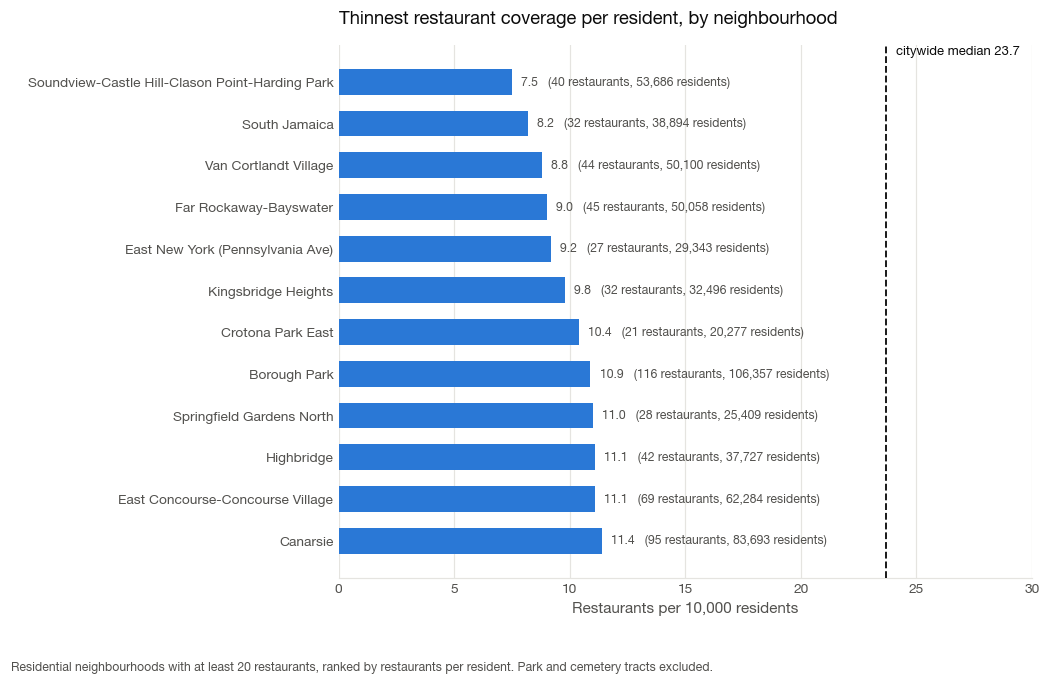

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))

d = thin.head(12).sort_values("per_10k", ascending=False)
labels = [f"{r.nta_name}" for r in d.itertuples()]
y = np.arange(len(d))

bars = ax.barh(y, d["per_10k"], color=BLUE, height=0.62)
ax.set_yticks(y)
ax.set_yticklabels(labels)

for i, r in enumerate(d.itertuples()):
    ax.text(r.per_10k + 0.4, i, f"{r.per_10k}   ({r.restaurants} restaurants, "
                                f"{r.population:,} residents)",
            va="center", fontsize=8, color=INK_SOFT)

ax.axvline(city_median, color=INK, lw=1.2, ls="--", zorder=3)
ax.text(city_median + 0.4, len(d) - 0.35, f"citywide median {city_median:.1f}",
        fontsize=8.5, color=INK, style="italic")

ax.set_xlabel("Restaurants per 10,000 residents")
ax.set_xlim(0, 30)
ax.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax.grid(axis="x", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)

ax.set_title("Thinnest restaurant coverage per resident, by neighbourhood", loc="left")
fig.text(0.0, -0.06,
         f"Residential neighbourhoods with at least {MIN_STORES_PC} restaurants, ranked by "
         "restaurants per resident. Park and cemetery tracts excluded.",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "11_underserved_neighbourhoods.png")
plt.show()

**Reading the chart**

The two ends of this distribution are different phenomena, not two points on one scale.

**Midtown-Midtown South** has 2,258 restaurants for 28,630 residents — **788.7 per 10,000**,
33x the citywide median of 23.7. No resident population supports that; it is fed by commuters
and tourists. The same applies, in order, to SoHo-TriBeCa, the East Village, Hudson Yards-Chelsea
and Lower Manhattan. Per-capita density is the wrong metric for these places.

At the other end sit large residential neighbourhoods with genuinely thin coverage:
**Soundview-Castle Hill** (40 restaurants for 53,686 residents, 7.5 per 10,000),
**South Jamaica** (8.2), **Van Cortlandt Village** (8.8). **Borough Park** is the most
striking of all — 106,357 residents, the largest population in this group, served by
116 restaurants.

Across the 188 residential neighbourhoods the spread runs from 2.8 to 788.7 — **282x**, or
105x if the list is restricted to neighbourhoods with at least 20 restaurants. Either figure
dwarfs the 4.1x that separated the top and bottom boroughs in Notebook 02. The same caution still applies: thin coverage per resident is a question worth
asking, not an answered one. Income, household size and cooking habits all move this number,
and none of them are in this dataset.

## 8. Summary

### Findings

1. **Restaurants follow a corridor, not borough boundaries** — one continuous dense spine
   runs through Manhattan into north-west Brooklyn and western Queens, then falls away
   sharply. It crosses three boroughs and respects none of them.
2. **Borough averages describe almost no actual neighbourhood.** Manhattan's NTAs range from
   11 to 2,258 restaurants, a **205x** spread. Brooklyn spans 41x, Queens 34x.
3. **The within-borough gap dwarfs the between-borough gap.** Notebook 02's headline finding
   — Manhattan is 4.1x the Bronx — is smaller than the spread between two Bronx
   neighbourhoods (14x).
4. **One NTA outweighs a borough.** `MN17` holds 2,258 restaurants, comparable to the whole
   Bronx (2,632) spread over 38 NTAs.
5. **Size and variety are not the same thing.** Diversity plateaus around 3.2 past ~200
   restaurants, and several large neighbourhoods sit far below it — **Flushing** has 500+
   restaurants at a diversity of 1.99, which its reputation as a single-cuisine destination
   explains better than any supply shortfall would.
6. **Per-capita density separates destinations from neighbourhoods.** Midtown carries 788.7
   restaurants per 10,000 residents against a median of 23.7 — a 282x spread across
   residential neighbourhoods, interpretable only once the two kinds of place are told apart.

### What this changes

Any market analysis in this project should be done at **NTA level, not borough level**.
Borough figures are useful as headlines and useless as a basis for siting decisions.

### Caveats

- 805 restaurants (2.6%) have no coordinates or NTA code and are absent from every map here
- Bubble positions are the mean coordinate of an NTA's restaurants, not official centroids —
  fine for locating a neighbourhood, not for measuring area or adjacency
- **Two population vintages are in play**: borough density uses the 2020 Census, while
  neighbourhood density uses 2010 figures, because the 2010 NTA geography our data is coded
  against has no 2020 population release. The two are not directly comparable
- **2010 NTA polygons are no longer published** on NYC Open Data — only the incompatible
  2020 generation is. A true neighbourhood choropleth still is not possible from open
  sources; the bubble map is the closest available substitute
- Park, cemetery and airport tracts are excluded from per-capita analysis; their token
  populations produce meaningless ratios

### Next steps

- Source 2010 NTA polygons from the NYC Planning archive (not on the open data portal) for
  a true neighbourhood choropleth
- Bring in census income and demographics to separate genuine gaps from differing demand —
  the open question left by Notebook 02, now answerable at neighbourhood resolution
- Cross-analyse `inspections.csv` to test whether hygiene performance varies geographically